In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
orders=pd.read_csv(r"D:\Data Analyst\EXCEL\supplychain\FACT_ORDERS.csv")
orders.head()

,order_line_id,order_id,date_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id,...,return_date,customer_rating,review_text,sentiment_score,delivery_delay_days,delivery_sla_days,gross_amount,discount_amount,tax_amount,net_amount
0,OL00000001,ORD0210788,2026-02-20,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,...,NaN,4.4,Very soft and baby-friendly material.,0.84,0,2,39998,3863.8068,1999.90,38220.7332
1,OL00000002,ORD0248321,2025-12-02,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,...,NaN,4.3,Stitching is neat and well-finished.,0.66,1,1,9996,703.7184,499.80,10007.8716
2,OL00000003,ORD0377603,2025-04-03,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,...,NaN,4.6,Highly enjoyable and worth it.,0.44,1,2,449995,25874.7125,22499.75,446706.6775
3,OL00000004,ORD0019414,2025-06-01,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,...,NaN,4.6,Fits perfectly in my space.,0.28,0,2,4497,27.4317,224.85,4781.0583
4,OL00000005,ORD0157859,2025-10-25,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,...,NaN,4.0,Strong and long-lasting material.,0.35,0,1,598,26.3718,29.90,817.3182


In [4]:
df=orders.copy()

In [5]:
df.columns

Index(['order_line_id', 'order_id', 'date_id', 'order_date', 'customer_id',
       'product_id', 'category', 'seller_id', 'seller_rating', 'location_id',
       'delivery_person_id', 'payment_id', 'campaign_id', 'fulfillment_id',
       'quantity', 'unit_price', 'discount_percentage', 'tax_percentage',
       'shipping_fee', 'expected_delivery_date', 'actual_delivery_date',
       'delivery_rating', 'order_status', 'return_flag', 'refund_amount',
       'return_date', 'customer_rating', 'review_text', 'sentiment_score',
       'delivery_delay_days', 'delivery_sla_days', 'gross_amount',
       'discount_amount', 'tax_amount', 'net_amount'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790732 entries, 0 to 790731
Data columns (total 35 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_line_id           790732 non-null  object 
 1   order_id                790732 non-null  object 
 2   date_id                 790732 non-null  object 
 3   order_date              790732 non-null  object 
 4   customer_id             790732 non-null  object 
 5   product_id              790732 non-null  object 
 6   category                790732 non-null  object 
 7   seller_id               790732 non-null  object 
 8   seller_rating           751390 non-null  float64
 9   location_id             790732 non-null  object 
 10  delivery_person_id      790732 non-null  object 
 11  payment_id              790732 non-null  object 
 12  campaign_id             790732 non-null  object 
 13  fulfillment_id          790732 non-null  object 
 14  quantity            

In [7]:
df.describe()

,seller_rating,quantity,unit_price,discount_percentage,tax_percentage,shipping_fee,delivery_rating,refund_amount,customer_rating,sentiment_score,delivery_delay_days,delivery_sla_days,gross_amount,discount_amount,tax_amount,net_amount
count,751390.000000,790732.000000,7.907320e+05,790732.000000,790732.0,790732.000000,751390.000000,790732.000000,751390.000000,790732.000000,790732.000000,790732.000000,7.907320e+05,790732.000000,790732.000000,7.907320e+05
mean,3.934732,3.001877,1.443109e+04,4.998254,5.0,116.332926,3.999883,-15.148007,3.718927,0.379188,0.450298,2.663600,4.322148e+04,2156.610857,2161.074214,4.334228e+04
std,0.911800,1.413882,5.030919e+04,2.886348,0.0,72.308419,0.857078,47.047367,0.910232,0.455638,0.668581,1.698761,1.670267e+05,9589.267398,8351.335561,1.672835e+05
min,1.000000,1.000000,2.000000e+01,0.000000,5.0,46.270000,1.000000,-215.790000,1.000000,-1.000000,0.000000,1.000000,2.000000e+01,0.000000,1.000000,6.536000e+01
25%,3.700000,2.000000,6.990000e+02,2.500000,5.0,46.270000,3.600000,0.000000,3.300000,0.180000,0.000000,1.000000,1.598000e+03,56.780100,79.900000,1.743271e+03
50%,4.100000,3.000000,1.999000e+03,4.990000,5.0,86.640000,4.200000,0.000000,3.800000,0.450000,0.000000,2.000000,5.397000e+03,220.310400,269.850000,5.480861e+03
75%,4.600000,4.000000,8.499000e+03,7.500000,5.0,215.790000,4.600000,0.000000,4.400000,0.730000,1.000000,5.000000,2.249500e+04,974.610000,1124.750000,2.240403e+04
max,5.000000,5.000000,1.150000e+06,10.000000,5.0,215.790000,5.000000,0.000000,5.000000,1.000000,2.000000,5.000000,5.750000e+06,572700.000000,287500.000000,6.031796e+06


In [8]:
df=df[['order_line_id', 'order_date', 'customer_id',
       'product_id', 'category', 'seller_id', 'seller_rating', 'location_id',
       'delivery_person_id', 'payment_id', 'campaign_id', 'fulfillment_id',
       'quantity', 'unit_price', 'discount_percentage', 'tax_percentage',
       'shipping_fee', 'actual_delivery_date',
       'delivery_rating', 'order_status', 'return_flag', 'refund_amount',
       'return_date', 'customer_rating', 'review_text', 'sentiment_score',
       'delivery_delay_days', 'gross_amount',
       'discount_amount', 'tax_amount', 'net_amount']]

In [9]:
df.head()

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id,delivery_person_id,payment_id,...,refund_amount,return_date,customer_rating,review_text,sentiment_score,delivery_delay_days,gross_amount,discount_amount,tax_amount,net_amount
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,0.0,NaN,4.4,Very soft and baby-friendly material.,0.84,0,39998,3863.8068,1999.90,38220.7332
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,0.0,NaN,4.3,Stitching is neat and well-finished.,0.66,1,9996,703.7184,499.80,10007.8716
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,0.0,NaN,4.6,Highly enjoyable and worth it.,0.44,1,449995,25874.7125,22499.75,446706.6775
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,0.0,NaN,4.6,Fits perfectly in my space.,0.28,0,4497,27.4317,224.85,4781.0583
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,0.0,NaN,4.0,Strong and long-lasting material.,0.35,0,598,26.3718,29.90,817.3182


In [10]:
df.isna().sum()

order_line_id                0
order_date                   0
customer_id                  0
product_id                   0
category                     0
seller_id                    0
seller_rating            39342
location_id                  0
delivery_person_id           0
payment_id                   0
campaign_id                  0
fulfillment_id               0
quantity                     0
unit_price                   0
discount_percentage          0
tax_percentage               0
shipping_fee                 0
actual_delivery_date         0
delivery_rating          39342
order_status                 0
return_flag                  0
refund_amount                0
return_date             687697
customer_rating          39342
review_text              39342
sentiment_score              0
delivery_delay_days          0
gross_amount                 0
discount_amount              0
tax_amount                   0
net_amount                   0
dtype: int64

In [13]:
missing_values=df[['seller_rating','return_date','delivery_rating','customer_rating','review_text']]

In [16]:
missing_values.describe()

,seller_rating,delivery_rating,customer_rating
count,751390.000000,751390.000000,751390.000000
mean,3.934732,3.999883,3.718927
std,0.911800,0.857078,0.910232
min,1.000000,1.000000,1.000000
25%,3.700000,3.600000,3.300000
50%,4.100000,4.200000,3.800000
75%,4.600000,4.600000,4.400000
max,5.000000,5.000000,5.000000


<Axes: ylabel='seller_rating'>

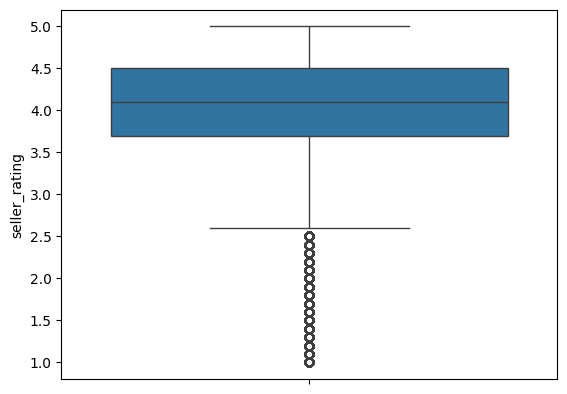

In [25]:
#seller_rating

sns.boxplot(data=df,y='seller_rating')

In [ ]:
# filling seller_rating with mean
df['seller_rating']=df['seller_rating'].fillna(df['seller_rating'].mean())

<Axes: ylabel='delivery_rating'>

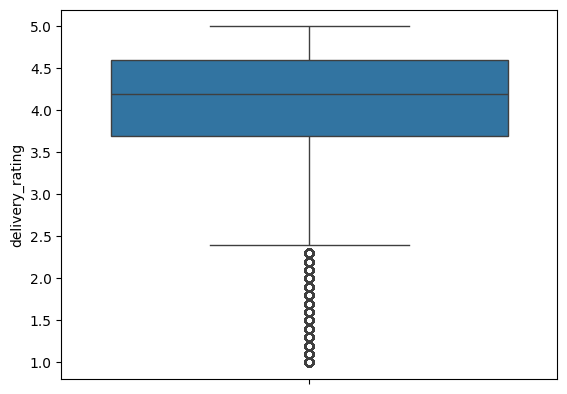

In [26]:
#delivery_rating

sns.boxplot(data=df,y='delivery_rating')

In [ ]:
# filling delivery_rating with mean
df['delivery_rating']=df['delivery_rating'].fillna(df['delivery_rating'].mean())

<Axes: ylabel='customer_rating'>

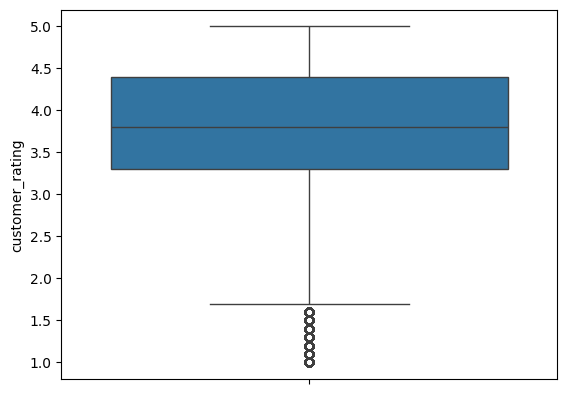

In [28]:
#customer_rating

sns.boxplot(data=df,y='customer_rating')

In [21]:
# filling customer_rating with mean
df['customer_rating']=df['customer_rating'].fillna(df['customer_rating'].mean())

In [23]:
df.isna().sum()

order_line_id                0
order_date                   0
customer_id                  0
product_id                   0
category                     0
seller_id                    0
seller_rating                0
location_id                  0
delivery_person_id           0
payment_id                   0
campaign_id                  0
fulfillment_id               0
quantity                     0
unit_price                   0
discount_percentage          0
tax_percentage               0
shipping_fee                 0
actual_delivery_date         0
delivery_rating              0
order_status                 0
return_flag                  0
refund_amount                0
return_date             687697
customer_rating              0
review_text              39342
sentiment_score              0
delivery_delay_days          0
gross_amount                 0
discount_amount              0
tax_amount                   0
net_amount                   0
dtype: int64

In [29]:
df['return_date']=pd.to_datetime(df['return_date'])

In [31]:
df['return_date'].isnull().sum()

np.int64(687697)

In [32]:
df.isna().sum()

order_line_id                0
order_date                   0
customer_id                  0
product_id                   0
category                     0
seller_id                    0
seller_rating                0
location_id                  0
delivery_person_id           0
payment_id                   0
campaign_id                  0
fulfillment_id               0
quantity                     0
unit_price                   0
discount_percentage          0
tax_percentage               0
shipping_fee                 0
actual_delivery_date         0
delivery_rating              0
order_status                 0
return_flag                  0
refund_amount                0
return_date             687697
customer_rating              0
review_text              39342
sentiment_score              0
delivery_delay_days          0
gross_amount                 0
discount_amount              0
tax_amount                   0
net_amount                   0
dtype: int64

In [34]:
df['return_date']=df['return_date'].fillna(0)

In [35]:
df.isna().sum()

order_line_id               0
order_date                  0
customer_id                 0
product_id                  0
category                    0
seller_id                   0
seller_rating               0
location_id                 0
delivery_person_id          0
payment_id                  0
campaign_id                 0
fulfillment_id              0
quantity                    0
unit_price                  0
discount_percentage         0
tax_percentage              0
shipping_fee                0
actual_delivery_date        0
delivery_rating             0
order_status                0
return_flag                 0
refund_amount               0
return_date                 0
customer_rating             0
review_text             39342
sentiment_score             0
delivery_delay_days         0
gross_amount                0
discount_amount             0
tax_amount                  0
net_amount                  0
dtype: int64